# Timeline of visual changes

Queries the `scene_capsule_test` GraphDB repository for the scenes pushed by `cltl.situation_awareness` and builds a timeline of what was seen per scene capture (a `grasp:Experience`).

Each experience denotes a claim graph in which the situation has its objects as `sem:hasActor`. The time of an experience is:

1. the `sem:hasTime` of the situation in that claim graph (added by `get_capsule_from_scene`), else
2. the `sem:hasBeginTimeStamp` of the experience itself.

Experiences without either time are listed at the end.

In [10]:
from collections import defaultdict
from datetime import datetime

from SPARQLWrapper import SPARQLWrapper, JSON

KG_ADDRESS = "http://localhost:7200/repositories/scene_capsule_test"
KG_ADDRESS = "http://localhost:7200/repositories/event_sandbox"

In [11]:
QUERY = """
PREFIX gaf: <http://groundedannotationframework.org/gaf#>
PREFIX grasp: <http://groundedannotationframework.org/grasp#>
PREFIX sem: <http://semanticweb.cs.vu.nl/2009/11/sem/>
PREFIX n2mu: <http://cltl.nl/leolani/n2mu/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?experience ?situation ?situationLabel ?time ?semTime ?experienceTime ?objectLabel
WHERE {
    ?experience a grasp:Experience ;
        gaf:denotes ?claim .
    GRAPH ?claim { ?situation sem:hasActor ?object . }
    ?situation a n2mu:situation ;
        rdfs:label ?situationLabel .
    ?object rdfs:label ?objectLabel .
    OPTIONAL {
        GRAPH ?claim { ?situation sem:hasTime ?time . }
        OPTIONAL { ?time rdfs:label ?semTime . }
    }
    OPTIONAL { ?experience sem:hasBeginTimeStamp ?experienceTime . }
}
"""

sparql = SPARQLWrapper(KG_ADDRESS)
sparql.setQuery(QUERY)
sparql.setReturnFormat(JSON)
rows = [{key: value["value"] for key, value in binding.items()}
        for binding in sparql.query().convert()["results"]["bindings"]]
len(rows)

156

In [12]:
def parse_sem_time(row):
    """The label of the sem:hasTime object, else its URI, where the colons of the time are dashes."""
    if "semTime" in row:
        return datetime.fromisoformat(row["semTime"])
    if "time" in row:
        date, _, time = row["time"].rsplit("/", 1)[-1].partition("T")
        return datetime.fromisoformat(f"{date}T{time.replace('-', ':')}")
    return None


def parse_experience_time(row):
    """The experience timestamp is stored as str(datetime), e.g. '2026-10-06 11:26:12.123456'."""
    return datetime.fromisoformat(row["experienceTime"]) if "experienceTime" in row else None


experiences = {}
for row in rows:
    experience = experiences.setdefault(row["experience"], {
        "experience": row["experience"],
        "situation": row["situation"],
        "scene": row["situationLabel"],
        "time": None,
        "time_source": None,
        "objects": set(),
    })
    experience["objects"].add(row["objectLabel"])
    if experience["time_source"] != "semTime":
        sem_time, experience_time = parse_sem_time(row), parse_experience_time(row)
        if sem_time:
            experience["time"], experience["time_source"] = sem_time, "semTime"
        elif experience_time and not experience["time"]:
            experience["time"], experience["time_source"] = experience_time, "experience"

timed = sorted((e for e in experiences.values() if e["time"]), key=lambda e: e["time"])
untimed = [e for e in experiences.values() if not e["time"]]
print(f"{len(experiences)} experiences: {len(timed)} with a time, {len(untimed)} without")

9 experiences: 9 with a time, 0 without


## Timeline per situation

For each situation, the objects seen at each capture, with the objects that appeared (`+`) and disappeared (`-`) since the previous capture.

In [13]:
timeline = defaultdict(list)
for experience in timed + untimed:
    timeline[experience["situation"]].append(experience)

for situation, captures in timeline.items():
    print(f"== {captures[0]['scene']} ({situation})")
    previous = set()
    for capture in captures:
        time = capture["time"].isoformat(sep=" ", timespec="seconds") if capture["time"] else "unknown time"
        added, removed = capture["objects"] - previous, previous - capture["objects"]
        print(f"{time} [{capture['time_source'] or '-'}] {len(capture['objects'])} objects")
        if added:
            print(f"    + {', '.join(sorted(added))}")
        if removed:
            print(f"    - {', '.join(sorted(removed))}")
        previous = capture["objects"]
    print()

== office (http://cltl.nl/leolani/world/office_02c5403b-c6c7-416b-be44-d30565af762a)
2026-10-06 13:16:00 [semTime] 23 objects
    + blazer, blinds, bottle, can, chair, coat, coat hanger, coat rack, glasses, glove, gloves, helmet, lanyard, light fixture, man, painting, poster, shirt, wall, wall outlet, watch, window, window blind
2026-10-06 13:16:00 [semTime] 23 objects
2026-10-06 13:16:00 [semTime] 23 objects
2026-10-06 13:17:00 [semTime] 14 objects
    - blinds, can, chair, coat hanger, glove, light fixture, wall outlet, watch, window
2026-10-06 13:18:00 [semTime] 15 objects
    + light switch, water bottle
    - bottle
2026-10-06 13:18:00 [semTime] 15 objects
2026-10-06 13:19:00 [semTime] 15 objects
    + blinds, jacket, necklace, window
    - blazer, lanyard, light switch, window blind
2026-10-06 13:20:00 [semTime] 14 objects
    + blazer, bottle, lanyard, window blind
    - blinds, jacket, necklace, water bottle, window
2026-10-06 13:21:00 [semTime] 14 objects
    + blinds, hand, j

## Visualisation of the timeline

Per situation the objects (rows, in order of first appearance) seen at each capture (columns, in time order), with the number of objects per capture above. The text timeline above lists the same changes.

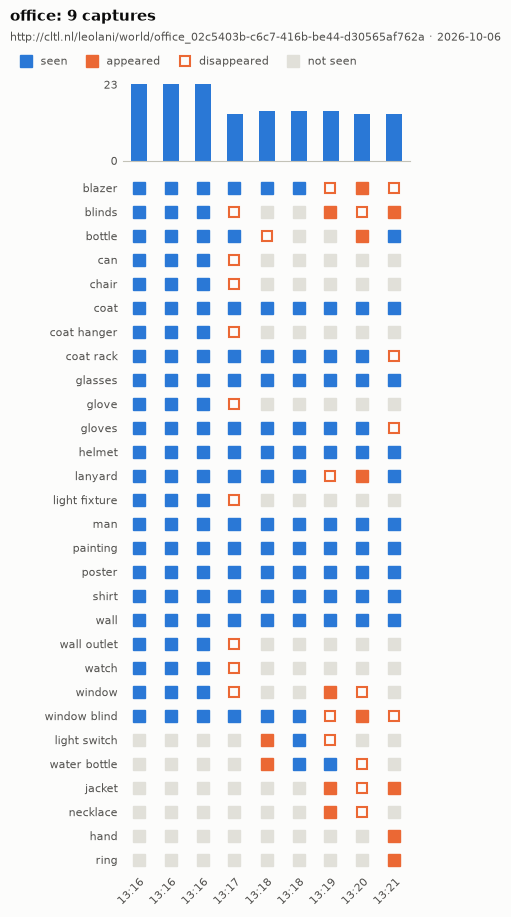

In [14]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Reference palette (light mode): the chart surface, text and the categorical slots 1 and 2
SURFACE, TEXT, TEXT_SECONDARY = "#fcfcfb", "#0b0b0b", "#52514e"
GRIDLINE, BASELINE = "#e1e0d9", "#c3c2b7"
SEEN, CHANGED = "#2a78d6", "#eb6834"

# Layout in inches
COLUMN, ROW, HEADER, BARS, FOOTER = 0.32, 0.24, 0.85, 0.8, 0.55
CELL = 8  # marker size in points


def capture_time(capture):
    return capture["time"].strftime("%H:%M") if capture["time"] else "?"


def plot_timeline(situation, captures):
    # Objects in order of first appearance
    objects = list(dict.fromkeys(label for capture in captures for label in sorted(capture["objects"])))
    dates = sorted({capture["time"].date().isoformat() for capture in captures if capture["time"]})

    left = 0.3 + 0.075 * max(len(label) for label in objects)
    width = max(5.5, left + COLUMN * len(captures) + 0.3)
    height = HEADER + BARS + 0.15 + ROW * len(objects) + FOOTER
    fig = plt.figure(figsize=(width, height), facecolor=SURFACE)
    plot_width = COLUMN * len(captures) / width
    grid = fig.add_axes((left / width, FOOTER / height, plot_width, ROW * len(objects) / height))
    bars = fig.add_axes((left / width, (height - HEADER - BARS) / height, plot_width, BARS / height), sharex=grid)

    fig.text(0.15 / width, 1 - 0.25 / height, f"{captures[0]['scene']}: {len(captures)} captures",
             color=TEXT, fontsize=11, fontweight="bold")
    fig.text(0.15 / width, 1 - 0.45 / height, situation + (" · " + ", ".join(dates) if dates else ""),
             color=TEXT_SECONDARY, fontsize=8)
    legend = [Line2D([], [], marker="s", linestyle="", markersize=CELL, color=SEEN, label="seen"),
              Line2D([], [], marker="s", linestyle="", markersize=CELL, color=CHANGED, label="appeared"),
              Line2D([], [], marker="s", linestyle="", markersize=CELL - 1, markerfacecolor="none",
                     markeredgecolor=CHANGED, markeredgewidth=1.5, label="disappeared"),
              Line2D([], [], marker="s", linestyle="", markersize=CELL, color=GRIDLINE, label="not seen")]
    fig.legend(handles=legend, loc="upper left", bbox_to_anchor=(0.1 / width, 1 - 0.5 / height), ncol=4,
               frameon=False, fontsize=8, labelcolor=TEXT_SECONDARY, handletextpad=0.3, columnspacing=1.2)

    counts = [len(capture["objects"]) for capture in captures]
    bars.bar(range(len(captures)), counts, width=0.5, color=SEEN)
    bars.set_yticks([0, max(counts)])
    bars.tick_params(labelbottom=False)

    previous = set()
    for column, capture in enumerate(captures):
        added, removed = capture["objects"] - previous, previous - capture["objects"]
        for row, label in enumerate(objects):
            if label in capture["objects"]:
                color = CHANGED if column and label in added else SEEN
                grid.plot(column, row, "s", markersize=CELL, color=color)
            elif label in removed:
                grid.plot(column, row, "s", markersize=CELL - 1, markerfacecolor="none",
                          markeredgecolor=CHANGED, markeredgewidth=1.5)
            else:
                grid.plot(column, row, "s", markersize=CELL, color=GRIDLINE)
        previous = capture["objects"]

    grid.set_xlim(-0.5, len(captures) - 0.5)
    grid.set_ylim(len(objects) - 0.5, -0.5)
    grid.set_yticks(range(len(objects)), objects)
    grid.set_xticks(range(len(captures)), [capture_time(capture) for capture in captures],
                    rotation=45, ha="right", rotation_mode="anchor")

    for ax in (bars, grid):
        ax.set_facecolor(SURFACE)
        ax.tick_params(colors=TEXT_SECONDARY, labelsize=8, length=0)
        for side, spine in ax.spines.items():
            spine.set_visible(ax is bars and side == "bottom")
            spine.set_color(BASELINE)

    return fig


figures = {}
for situation, captures in timeline.items():
    figures[situation] = plot_timeline(situation, captures)
    plt.show()


## Save the timelines as PNG

Saves each figure in the `notebooks` folder as `timeline_<situation>.png`.

In [17]:
from pathlib import Path

# Jupyter runs the notebook in its own folder, other environments may run it from the project root
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"

for situation, fig in figures.items():
    path = NOTEBOOK_DIR / "timelines" / f"timeline_{situation.rsplit('/', 1)[-1]}.png"
    fig.savefig(path, dpi=150, facecolor=SURFACE)
    print(f"Saved {path}")

Saved /Users/piek/Desktop/Leolani/cltl-apps/cltl-custom-object-recognition/notebooks/timelines/timeline_office_02c5403b-c6c7-416b-be44-d30565af762a.png
